# CMIP6 Precipitation Validation Against ERA5 Reanalysis

---

## Overview
In this notebook total precipitation from a 5-model ensemble of historical CMIP6 runs will be compared to ERA5 reanalysis over Oceania. ERA5 is accessed via Destination Earth in zarr file format.

1. Load in CMIP6 data
1. Load in ERA5 data
1. Validation of CMIP6 against ERA5


## Prerequisites

A complete understaning of the 01_CMIP6_Precipitation_Analysis is neccessary to understand the beginning of this notebook. A basic understanding of matplotlib, xarray, and numpy are needed for this notebook.


| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Helpful | |
| Familiarity with metadata structure| Helpful |  |
| Project management | Helpful | |

- **Time to learn**: 10 minutes
- **System requirements**:
    - Populate with any system, version, or non-Python software requirements if necessary
    - Otherwise use the concepts table above and the Imports section below to describe required packages as necessary
    - If no extra requirements, remove the **System requirements** point altogether

## Imports

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import fsspec
import intake
import xesmf as xe
from scipy.stats import pearsonr
from matplotlib import colors
import warnings
%matplotlib inline

## Load in CMIP6 data

Here, we will load in the desired CMIP6 data with intake-esm in just one cell. This section is covered in greater detail in the notebook 01_CMIP6_Precipitation_Analysis.

:::{note}
The RuntimeWarning that is thrown when converting time indexes arises from discrepancies when accounting for leap years in time indexes. This should not significantly impact the long term analysis we are conducting in this notebook!
:::

In [2]:
## ignore some warnings
warnings.filterwarnings('ignore', category=UserWarning)

datasets = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")

cat = datasets.search(experiment_id=['historical'], table_id='Amon', variable_id='pr', 
                    source_id=['CESM2','AWI-ESM-1-1-LR','BCC-ESM1','NorESM2-LM','MRI-ESM2-0'],
grid_label='gn', member_id='r1i1p1f1')

dset_dict = cat.to_dataset_dict(zarr_kwargs={'consolidated': True})

## make and xarray Dataset with the standardized lat lons of interest
standard_grid = xr.Dataset(
    coords={'lat': np.arange(-90, 90.1, 1), 'lon': np.arange(0, 360, 1)})

## intialize a list to populate with the standardized data
p = []

## loop through each model
for i in dset_dict.keys():
    ## lets get rid of unecessary dimensions in each dataset
    x = dset_dict[i]['pr'].isel(member_id=0, dcpp_init_year=0)

    ## lets take the time we are interested in 1950-2009
    x = x.sel(time=slice("1950-01-01", "2009-12-31"))

    ## If the current time dimension of the model member is not a datetime64 object, change it to be one
    if x['time'].dtype != 'datetime64[ns]':
        dt = x.indexes['time'].to_datetimeindex()
        x['time'] = dt


    ## regrid using xesmf onto standard grid
    regridder = xe.Regridder(x, standard_grid, method='conservative', periodic=True)
    x_i = regridder(x)
    
    p.append(x_i)

## I was having issues concatonating these models while retaining 720 time increments since different models 
## defined different dates to be mid-month.
## The following code, which was helped along by chat GPT, standardizes date conventions
for idx, x_i in enumerate(p):
    p[idx]['time'] = x_i['time'].values.astype('datetime64[M]') + np.timedelta64(14, 'D')

## take the list p and convert it into an xarray with dimension model named for the original dset_dict keys
pr_s = xr.concat(p, dim='model')
pr_s = pr_s.assign_coords(model=list(dset_dict.keys()))


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


/tmp/ipykernel_3516632/2989787732.py:29: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  dt = x.indexes['time'].to_datetimeindex()
/tmp/ipykernel_3516632/2989787732.py:29: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dt = x.indexes['time'].to_datetimeindex()
/tmp/ipykernel_3516632/2989787732.py:29: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  dt = x.indexes['time'].to_date

With the data now loaded into the notebook it can be subset to only include the region of interest, in this case Oceania.

In [3]:
## Define Region
lat_s = -25
lat_n = 25
lon_w = 100
lon_e = 180

## subset CMIP6 data to only include the region of interest
pr_reg_cmip = pr_s.sel(lat=slice(lat_s, lat_n), lon=slice(lon_w, lon_e))

## Load in ERA5 Reanalysis Data from the Google Cloud

Here we will load in monthly ERA5 Reanalysis data from Destination Earth as a zarr file using xarray. 

In [4]:
ds = xr.open_dataset(
    'https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-monthly-means-v0.zarr',
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",

)
ds

<xarray.Dataset> Size: 34GB
Dimensions:     (valid_time: 1030, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-10-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    msl         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    sp          (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    sst         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-10-30T04:46 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Now that we have the dataset loaded into the notebook, the next step is to extract the variable of interest, total precipitation (tp), for the time frame of interest 1950-2009. 

In [5]:
tp = ds['tp'].sel(valid_time=slice("1950-01-01", "2009-12-31"))
tp

<xarray.DataArray 'tp' (valid_time: 720, latitude: 721, longitude: 1440)> Size: 3GB
dask.array<getitem, shape=(720, 721, 1440), dtype=float32, chunksize=(120, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 1950-01-01 ... 2009-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           tp
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_units:                               m
    GRIB_uvRelativeToGrid:                    0
    last_restart_dim_updated:                 1029
    long_name:                                Total precipitation
    standard_name:                            unknown
    units:                                    m

Since I could not find monthly 1 degree resolution ERA5 data that included the total precipitation variable in any cloud server, we will have to convert the 0.25 degree data to 1 degree to be compatable with the cmip6 data.

Code for regridding the data was modified from here: https://pavics-sdi.readthedocs.io/en/latest/notebooks/regridding.html

In [6]:
## Regrid to 1 degree
regridder_era = xe.Regridder(tp, standard_grid, method='conservative', periodic=True)
tp_rg = regridder_era(tp)

Now lets slice the data to just include our region of interest (which was defined in the previous section).

In [7]:
pr_reg_era = tp_rg.sel(lat=slice(lat_s, lat_n), lon=slice(lon_w, lon_e))
##convert from m to mm
pr_reg_era = pr_reg_era*1000

Now we have a global dataset on a 1 degree grid with monthly averaged total precipitation expressed in mm per day. 

## Validation of CMIP6 against ERA5

Make a plot comparing the emsemble mean time series of total precipitation in CMIP6 vs. ERA5 over Oceania

In [8]:
## Take the mean of all models over all lats and lons
region_mean_precip_cmip = pr_reg_cmip.mean(dim=['model','lat', 'lon'])*86400
region_mean_precip_era = pr_reg_era.mean(dim=['lat', 'lon'])


In [9]:
## since its a bit hard to see trends with the seasonal cycle lets resample to annual data and plot that
annual_mean_cmip = region_mean_precip_cmip.groupby('time.year').mean('time')
annual_mean_era = region_mean_precip_era.groupby('valid_time.year').mean('valid_time')

Text(0.5, 1.0, 'Average Precipitation over Oceania')

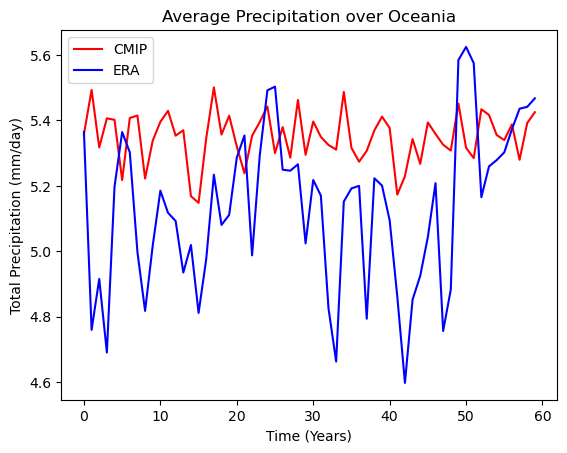

In [10]:
plt.plot(annual_mean_cmip,c='r', label='CMIP')
plt.plot(annual_mean_era,c='b', label='ERA')
plt.ylabel("Total Precipitation (mm/day)")
plt.xlabel("Time (Years)")
plt.legend()
plt.title("Average Precipitation over Oceania")

The two datasets don't appear to be in great agreement. The ensemble of CMIP6 does not capture the scale of interannual variability of precipitation in the real world and seems to overestimate precipitation. The smaller variability in the CMIP6 ensemble is likely a result of it just being an ensemble, meaning that averaging smooths over large variations. 

To truly compare the two datasets statitistics must be calculated and individual ensemble members should be viewed. 

First, we will calculate the Pearson correlation coeficient (CC) between the two lines in the above plot using the pearsonr function in scipy.stats. 

In [11]:
cc, p = pearsonr(annual_mean_cmip, annual_mean_era)

print(f"Correlation: {cc}")
print(f"P-value: {p}")

Correlation: 0.25037598609924316
P-value: 0.053673638300530006


A p-value of 0.054 is just outside of the 5% significance threshold, indicating that the relationship between the two datasets is not significant to the 5% level but awfully close. 

Let's se how each ensemble member fairs both visually and by calculating more CC's.

CESM2 mean: 5.3688459396362305
CESM2 Correlation: 0.26993101835250854
CESM2 P-value: 0.03699827927142866
MRI-ESM2-0 mean: 5.11503791809082
MRI-ESM2-0 Correlation: -0.04696815088391304
MRI-ESM2-0 P-value: 0.7215732687914164
NorESM2-LM mean: 5.445958614349365
NorESM2-LM Correlation: 0.08378344774246216
NorESM2-LM P-value: 0.5244819620288614
AWI-ESM-1-1-LR mean: 5.554451942443848
AWI-ESM-1-1-LR Correlation: 0.028428051620721817
AWI-ESM-1-1-LR P-value: 0.8292884218900722
BCC-ESM1 mean: 5.260107517242432
BCC-ESM1 Correlation: 0.32005417346954346
BCC-ESM1 P-value: 0.01266930758922408


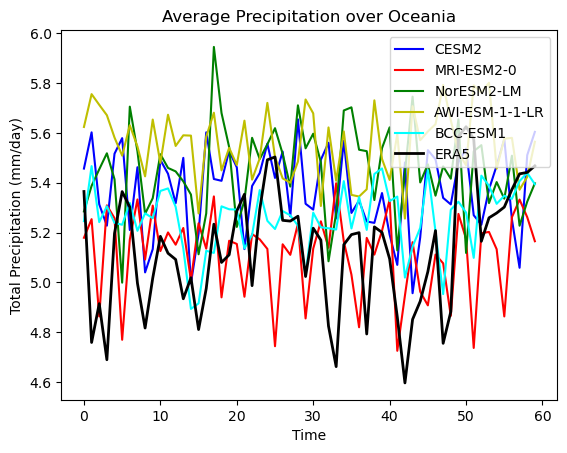

In [12]:
region_mean_precip_e = pr_reg_cmip.mean(dim=['lat', 'lon'])*86400

## make a list of colors to be used in the loop
c_list=['b','r','g','y','cyan']

## Get model names from datset strings
m_names = [s.split('.')[2] for s in pr_s.model.values]

for i in np.arange(0,5,1):
    p_a = region_mean_precip_e[i].groupby('time.year').mean('time')
    plt.plot(p_a, c=c_list[i], label=m_names[i])
    print(f"{m_names[i]} mean: {p_a.values.mean()}")
    cc_i, p_i = pearsonr(p_a, annual_mean_era)
    print(f"{m_names[i]} Correlation: {cc_i}")
    print(f"{m_names[i]} P-value: {p_i}")
    
    
plt.plot(annual_mean_era, c='k', label='ERA5',linewidth=2)

## Make some visual improvements to the plot
#plt.ylim(2.1,2.7)
plt.ylabel("Total Precipitation (mm/day)")
plt.xlabel("Time")
plt.title("Average Precipitation over Oceania")
plt.legend(loc='upper right')


Individual model members better capture the real-world variability in precipitation than the ensemble mean. The BCC-ESM1 does the best overall job of modeling the historical mean and variations in precipitation in this region.

Next, we will compare the spatial pattern of precipitation between CMIP and ERA5. We will do this by creating a three panel map plot with a panel for CMIP, a panel for ERA, and a panel for CMIP minus ERA5. 

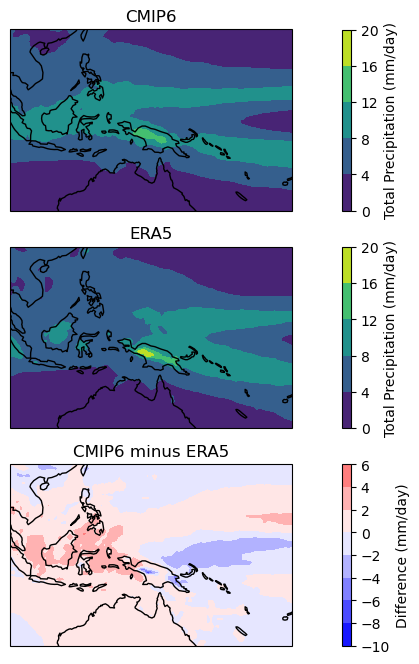

In [13]:
## Calculate mean
spatial_mean_precip_c = pr_reg_cmip.mean(dim=['model','time'])*86400
spatial_mean_precip_e = pr_reg_era.mean(dim=['valid_time'])

## Now lets plot this on a map
fig, ax = plt.subplots(nrows=3, figsize=(16, 8), subplot_kw={'projection': ccrs.Mercator()})

## add features
#ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
#ax.add_feature(cfeature.LAND, facecolor='darkgray')
ax[0].coastlines(linewidth=1)
ax[1].coastlines(linewidth=1)
ax[2].coastlines(linewidth=1)

## set domain to be just the area to the northwest of Svalbard
ax[0].set_extent([lon_e,lon_w,lat_s,lat_n],crs=ccrs.PlateCarree()) 
ax[1].set_extent([lon_e,lon_w,lat_s,lat_n],crs=ccrs.PlateCarree()) 
ax[2].set_extent([lon_e,lon_w,lat_s,lat_n],crs=ccrs.PlateCarree()) 

precip_cmip = ax[0].contourf(spatial_mean_precip_c.lon,spatial_mean_precip_c.lat,spatial_mean_precip_c,levels=np.arange(0,24,4),transform=ccrs.PlateCarree())
precip_era = ax[1].contourf(spatial_mean_precip_e.lon,spatial_mean_precip_e.lat,spatial_mean_precip_e,levels=np.arange(0,24,4),transform=ccrs.PlateCarree())
precip_dif = ax[2].contourf(spatial_mean_precip_e.lon,spatial_mean_precip_e.lat,spatial_mean_precip_c - spatial_mean_precip_e, cmap = 'bwr', norm=colors.CenteredNorm(), transform=ccrs.PlateCarree())

ax[0].set_title("CMIP6")
ax[1].set_title("ERA5")
ax[2].set_title("CMIP6 minus ERA5")

cb1 = fig.colorbar(precip_cmip, ax=ax[0], orientation='vertical', fraction=0.050, pad=0.04) 
cb2 = fig.colorbar(precip_era, ax=ax[1], orientation='vertical', fraction=0.050, pad=0.04) 
cb3 = fig.colorbar(precip_dif, ax=ax[2], orientation='vertical', fraction=0.050, pad=0.04) 

cb1.set_label("Total Precipitation (mm/day)")
cb2.set_label("Total Precipitation (mm/day)")
cb3.set_label("Difference (mm/day)")

### A loop would be a better way of doing this but copy and paste works for now.

The CMIP6 ensemble overestimates rainfall across much of Indonesia, while mountainous regions on the island of New Guinea and equitorial regions in the east of the domain see underestimates. 

## Summary
Reanalysis datasets, such as ERA5, provide a valuable opportunity to assess the accuracy of climate models over the historical period. This data is readily available on many cloud servers, which allow for quick, non-memory intensive analysis. 

### What's next?
No current suggestions, but I plan to greatly expand this notebook for the project

## Resources and references

Some useful links:
- Destination Earth: https://destination-earth.eu/
- Regridding: https://pavics-sdi.readthedocs.io/en/latest/notebooks/regridding.html